# Highlight Budget Amendment - Method 1 (Benchmark Route)

## Business question we want to answer

**Based on Debs/Viktoria Method 1 and the provided benchmark workbook, what budget multiplier should we apply to Porsche highlight investment (Tier 1) to estimate a realistic required highlight budget range vs competitors?**

The notebook answers this question in clear steps and ends with a direct recommendation.

In [ ]:
# Step 0 - Imports and paths
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

BASE = Path('/home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment')
FILE = BASE / 'DS edit INTERNAL ONLY Porsche 2025 Share of Spend Comparison 19.03.26 Funnel.xlsx'

print('Workbook exists:', FILE.exists())
print('Workbook path:', FILE)

Workbook exists: True
Workbook path: /home/ali/repos/porsche/budget_setting/highlight_budget_estimation/budget_setting_amendment/DS edit INTERNAL ONLY Porsche 2025 Share of Spend Comparison 19.03.26 Funnel.xlsx


In [ ]:
# Step 1 - Load workbook sheets we need
sheet_names = pd.ExcelFile(FILE).sheet_names
sheet_names

['Detailed Data',
 'Indexed Totals Calcs',
 'Sheet1',
 'Total Spend Chart',
 'US Index',
 'UK Index',
 'DE Indec',
 'Spend Index',
 'By Channel Pivot',
 'By Channel Chart',
 'Channel Funnel',
 'Comp figures',
 'Funnel Splits Pivot',
 'Funnel calc',
 'Funnel calc (2)',
 'Sheet2']

## Step 2 - Build analysis-ready base table from `Detailed Data`

This is our source-of-truth table for Method 1.

We keep only fields needed for benchmark multipliers:
- client
- market
- deb category
- spend

In [ ]:
raw = pd.read_excel(FILE, sheet_name='Detailed Data', header=3)
raw.columns = [str(c).strip() for c in raw.columns]

keep_cols = ['Client', 'Anonymised Client', 'Client Sector', 'Market', 'Deb Categories', '2025 Spend (EUR)']
df = raw[keep_cols].copy()

df = df.rename(columns={
    'Client': 'client',
    'Anonymised Client': 'anonymised_client',
    'Client Sector': 'client_sector',
    'Market': 'market',
    'Deb Categories': 'deb_category',
    '2025 Spend (EUR)': 'spend_eur'
})

# cleanup
df['client'] = df['client'].astype(str).str.strip()
df['anonymised_client'] = df['anonymised_client'].astype(str).str.strip()
df['client_sector'] = df['client_sector'].astype(str).str.strip()
df['market'] = df['market'].astype(str).str.strip()
df['deb_category'] = df['deb_category'].astype(str).str.strip()
df['spend_eur'] = pd.to_numeric(df['spend_eur'], errors='coerce')

df = df[df['spend_eur'].notna() & (df['spend_eur'] > 0)].copy()

print('Rows:', len(df))
print('Markets:', df['market'].nunique())
print('Clients:', df['client'].nunique())
print('Client sectors:', sorted(df['client_sector'].dropna().unique()))

df.head()

Rows: 1263
Markets: 48
Clients: 9
Client sectors: ['Auto', 'Fashion']


,client,anonymised_client,client_sector,market,deb_category,spend_eur
0,Chanel,Fashion 2,Fashion,Australia,Digital Video,582107.75
1,Chanel,Fashion 2,Fashion,Australia,Display,339478.70
2,Chanel,Fashion 2,Fashion,Australia,OOH,2600003.70
3,Chanel,Fashion 2,Fashion,Australia,Print,1127901.75
4,Chanel,Fashion 2,Fashion,Australia,Search,845997.80


## Step 3 - Define Porsche vs competitors and compute total multiplier

Method 1 core metric:

`multiplier_total = avg_competitor_spend / porsche_spend`

This gives the directional uplift factor for highlight budget sizing.

In [ ]:
# identify Porsche rows
is_porsche = (df['client'].str.upper() == 'PORSCHE') | (df['anonymised_client'].str.upper() == 'PORSCHE')

porsche = df[is_porsche].copy()

# competitors: keep only sectors containing "Auto"
auto_comp_mask = (~is_porsche) & (df['client_sector'].str.contains('auto', case=False, na=False))
comp = df[auto_comp_mask].copy()

porsche_total = porsche['spend_eur'].sum()

# per competitor brand total, then average brand total
comp_brand_totals = comp.groupby('anonymised_client', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'brand_total_spend'})
comp_avg_brand_total = comp_brand_totals['brand_total_spend'].mean()

multiplier_total = comp_avg_brand_total / porsche_total if porsche_total > 0 else np.nan

summary_total = pd.DataFrame({
    'metric': [
        'Porsche total spend',
        'Average AUTO competitor-brand total spend',
        'Total multiplier (avg AUTO competitor / Porsche)'
    ],
    'value': [porsche_total, comp_avg_brand_total, multiplier_total]
})

print('AUTO competitor brands used:', comp['anonymised_client'].nunique())
summary_total

AUTO competitor brands used: 6


,metric,value
0,Porsche total spend,1.596483e+08
1,Average AUTO competitor-brand total spend,1.042530e+09
2,Total multiplier (avg AUTO competitor / Porsche),6.530167e+00


## Step 4 - Market-level multiplier view

This shows where Porsche is furthest below competitor average in this dataset.

`multiplier_market = avg_competitor_spend_in_market / porsche_spend_in_market`

In [ ]:
porsche_market = porsche.groupby('market', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'porsche_spend'})

comp_market_brand = comp.groupby(['market', 'anonymised_client'], as_index=False)['spend_eur'].sum()
comp_market_avg = comp_market_brand.groupby('market', as_index=False)['spend_eur'].mean().rename(columns={'spend_eur': 'comp_avg_brand_spend'})

market_mult = porsche_market.merge(comp_market_avg, on='market', how='inner')
market_mult['multiplier_market'] = market_mult['comp_avg_brand_spend'] / market_mult['porsche_spend']
market_mult = market_mult.sort_values('multiplier_market', ascending=False)

market_mult.head(15)

,market,porsche_spend,comp_avg_brand_spend,multiplier_market
2,China,2.433910e+06,4.977178e+07,20.449309
6,Italy,1.483923e+06,2.494740e+07,16.811789
13,Spain,1.087161e+06,1.571302e+07,14.453261
4,France,1.641348e+06,2.016293e+07,12.284374
16,UK,4.471412e+06,5.043329e+07,11.279052
10,Portugal,4.497702e+05,3.589813e+06,7.981439
5,Germany,6.514020e+06,4.982749e+07,7.649269
17,USA,2.752236e+07,1.645446e+08,5.978580
14,Switzerland,1.493201e+06,8.434803e+06,5.648808
1,Canada,2.503786e+06,1.317256e+07,5.261058


## Step 4b - Funnel-adjusted benchmark layer

To include funnel logic, I use the workbook's funnel weights (`Funnel calc (2)`) and apply them to channel/category spend for Porsche and AUTO competitors.

Then I compute:
- multiplier by funnel stage (LOWER/MIDDLE/UPPER)
- a blended funnel-adjusted multiplier using Porsche's funnel mix as weights.

In [ ]:
# Infer funnel stage from channel weights (argmax by channel)
funnel_raw = pd.read_excel(FILE, sheet_name='Funnel calc (2)', header=None)

channels = funnel_raw.iloc[13, 1:12].tolist()  # B:L
lower_w = pd.to_numeric(funnel_raw.iloc[9, 1:12], errors='coerce').values
middle_w = pd.to_numeric(funnel_raw.iloc[10, 1:12], errors='coerce').values
upper_w = pd.to_numeric(funnel_raw.iloc[11, 1:12], errors='coerce').values

funnel_weights = pd.DataFrame({
    'deb_category': channels,
    'LOWER': lower_w,
    'MIDDLE': middle_w,
    'UPPER': upper_w,
})

# infer single funnel stage per channel using max weight
stage_cols = ['LOWER', 'MIDDLE', 'UPPER']
funnel_weights['funnel_stage'] = funnel_weights[stage_cols].idxmax(axis=1)

# merge stage onto spend data
fdf = df.merge(funnel_weights[['deb_category', 'funnel_stage']], on='deb_category', how='inner')

# split Porsche and AUTO competitors
f_is_porsche = (fdf['client'].str.upper() == 'PORSCHE') | (fdf['anonymised_client'].str.upper() == 'PORSCHE')
f_porsche = fdf[f_is_porsche].copy()
f_comp = fdf[(~f_is_porsche) & (fdf['client_sector'].str.contains('auto', case=False, na=False))].copy()

# Stage-level totals for chart 1
p_stage = f_porsche.groupby('funnel_stage', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'porsche_spend'})
comp_stage_brand = f_comp.groupby(['anonymised_client', 'funnel_stage'], as_index=False)['spend_eur'].sum()
comp_stage_avg = comp_stage_brand.groupby('funnel_stage', as_index=False)['spend_eur'].mean().rename(columns={'spend_eur': 'comp_avg_brand_spend'})

stage_summary = p_stage.merge(comp_stage_avg, on='funnel_stage', how='inner')
stage_summary['multiplier_stage'] = stage_summary['comp_avg_brand_spend'] / stage_summary['porsche_spend']

# Market-stage multipliers for chart 2 and chart 3
p_market_stage = f_porsche.groupby(['market', 'funnel_stage'], as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'porsche_spend'})
comp_market_stage_brand = f_comp.groupby(['market', 'anonymised_client', 'funnel_stage'], as_index=False)['spend_eur'].sum()
comp_market_stage_avg = comp_market_stage_brand.groupby(['market', 'funnel_stage'], as_index=False)['spend_eur'].mean().rename(columns={'spend_eur': 'comp_avg_brand_spend'})

market_stage = p_market_stage.merge(comp_market_stage_avg, on=['market', 'funnel_stage'], how='inner')
market_stage['multiplier'] = market_stage['comp_avg_brand_spend'] / market_stage['porsche_spend']

# exclude markets explicitly requested
market_stage = market_stage[market_stage['market'] != 'Canada'].copy()

# keep explicit stage order
stage_order = ['LOWER', 'MIDDLE', 'UPPER']
stage_summary['funnel_stage'] = pd.Categorical(stage_summary['funnel_stage'], categories=stage_order, ordered=True)
market_stage['funnel_stage'] = pd.Categorical(market_stage['funnel_stage'], categories=stage_order, ordered=True)
stage_summary = stage_summary.sort_values('funnel_stage')
market_stage = market_stage.sort_values(['market', 'funnel_stage'])

stage_summary

,funnel_stage,porsche_spend,comp_avg_brand_spend,multiplier_stage
0,LOWER,1.290929e+08,6.705539e+08,5.194352
1,MIDDLE,7.505769e+05,2.278595e+07,30.357912
2,UPPER,2.879890e+07,3.458648e+08,12.009653


## Step 5 - Scenario multipliers by funnel stage

Now we compute conservative/base/aggressive multipliers **separately for LOWER, MIDDLE, UPPER**.

Definitions:
- Conservative = 25th percentile of market multipliers
- Base = 50th percentile (median)
- Aggressive = 75th percentile

This keeps the scenario logic identical, but explicitly funnel-specific.

In [ ]:
current_budget_anchor = 17_000_000  # edit as needed

scenario_quantiles = {
    'Conservative': 0.25,
    'Base': 0.50,
    'Aggressive': 0.75,
}

records = []
for stage, g in market_stage.groupby('funnel_stage'):
    for scenario_name, q in scenario_quantiles.items():
        m = g['multiplier'].quantile(q)
        records.append({
            'scenario': scenario_name,
            'funnel_stage': str(stage),
            'multiplier': m,
            'recommended_budget_eur': m * current_budget_anchor,
            'gap_vs_current_eur': (m * current_budget_anchor) - current_budget_anchor,
        })

range_df = pd.DataFrame(records)
range_df = range_df.sort_values(['scenario', 'funnel_stage'])
range_df

/tmp/ipykernel_54030/3883357440.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stage, g in market_stage.groupby('funnel_stage'):


,scenario,funnel_stage,multiplier,recommended_budget_eur,gap_vs_current_eur
2,Aggressive,LOWER,9.054028,1.539185e+08,1.369185e+08
5,Aggressive,MIDDLE,9.599588,1.631930e+08,1.461930e+08
8,Aggressive,UPPER,22.540373,3.831863e+08,3.661863e+08
1,Base,LOWER,5.057286,8.597386e+07,6.897386e+07
4,Base,MIDDLE,3.867862,6.575366e+07,4.875366e+07
7,Base,UPPER,9.730256,1.654144e+08,1.484144e+08
0,Conservative,LOWER,3.564925,6.060373e+07,4.360373e+07
3,Conservative,MIDDLE,3.253533,5.531006e+07,3.831006e+07
6,Conservative,UPPER,5.259323,8.940848e+07,7.240848e+07


## Step 6 - Final answer to the business question

The question was:

**"What budget multiplier should we apply to Porsche highlight investment (Tier 1) to estimate a realistic required highlight budget range vs competitors?"**

We answer with the dataset-derived multiplier band and a plain-language recommendation.

In [284]:
print('ANSWER:')
for stage in ['LOWER', 'MIDDLE', 'UPPER']:
    s = range_df[range_df['funnel_stage'] == stage].set_index('scenario')
    cons_mult = float(s.loc['Conservative', 'multiplier'])
    base_mult = float(s.loc['Base', 'multiplier'])
    aggr_mult = float(s.loc['Aggressive', 'multiplier'])
    cons_budget = float(s.loc['Conservative', 'recommended_budget_eur'])
    base_budget = float(s.loc['Base', 'recommended_budget_eur'])
    aggr_budget = float(s.loc['Aggressive', 'recommended_budget_eur'])

    print(f'\n[{stage}]')
    print(f'- Multiplier range: {cons_mult:.2f}x to {aggr_mult:.2f}x (base {base_mult:.2f}x)')
    print(f'- Budget range on EUR {current_budget_anchor:,.0f} anchor: EUR {cons_budget:,.0f} to EUR {aggr_budget:,.0f} (base EUR {base_budget:,.0f})')

print('\nInterpretation: use stage-specific multipliers (Lower/Middle/Upper) instead of one single multiplier.')

ANSWER:

[LOWER]
- Multiplier range: 3.56x to 9.05x (base 5.06x)
- Budget range on EUR 17,000,000 anchor: EUR 60,603,733 to EUR 153,918,474 (base EUR 85,973,862)

[MIDDLE]
- Multiplier range: 3.25x to 9.60x (base 3.87x)
- Budget range on EUR 17,000,000 anchor: EUR 55,310,056 to EUR 163,193,001 (base EUR 65,753,661)

[UPPER]
- Multiplier range: 5.26x to 22.54x (base 9.73x)
- Budget range on EUR 17,000,000 anchor: EUR 89,408,485 to EUR 383,186,335 (base EUR 165,414,357)

Interpretation: use stage-specific multipliers (Lower/Middle/Upper) instead of one single multiplier.


## Step 7 - Story charts (for clear communication)

These charts are designed to make the narrative easy to follow:
1. **How far Porsche is from competitor benchmark** (overall)
2. **Where the gap is most severe by market** (multiplier view)
3. **What budget range this implies** (conservative/base/aggressive)


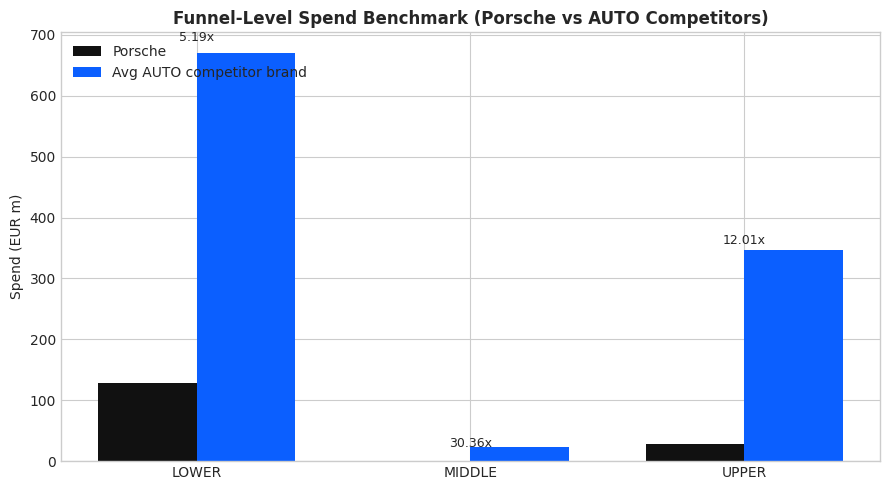

In [285]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Chart 1: stage-level benchmark gap (3 bars per group)
plot1 = stage_summary.copy()
plot1['porsche_m'] = plot1['porsche_spend'] / 1e6
plot1['comp_m'] = plot1['comp_avg_brand_spend'] / 1e6

x = np.arange(len(plot1))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, plot1['porsche_m'], width, label='Porsche', color='#111111')
b2 = ax.bar(x + width/2, plot1['comp_m'], width, label='Avg AUTO competitor brand', color='#0B5FFF')

ax.set_xticks(x)
ax.set_xticklabels(plot1['funnel_stage'])
ax.set_ylabel('Spend (EUR m)')
ax.set_title('Funnel-Level Spend Benchmark (Porsche vs AUTO Competitors)', fontsize=12, weight='bold')
ax.legend(loc='upper left')

for i, r in plot1.iterrows():
    ax.text(i, max(r['porsche_m'], r['comp_m']) * 1.03, f"{r['multiplier_stage']:.2f}x", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_54030/1669668881.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  market_pivot = market_stage.pivot_table(index='market', columns='funnel_stage', values='multiplier', aggfunc='mean').copy()


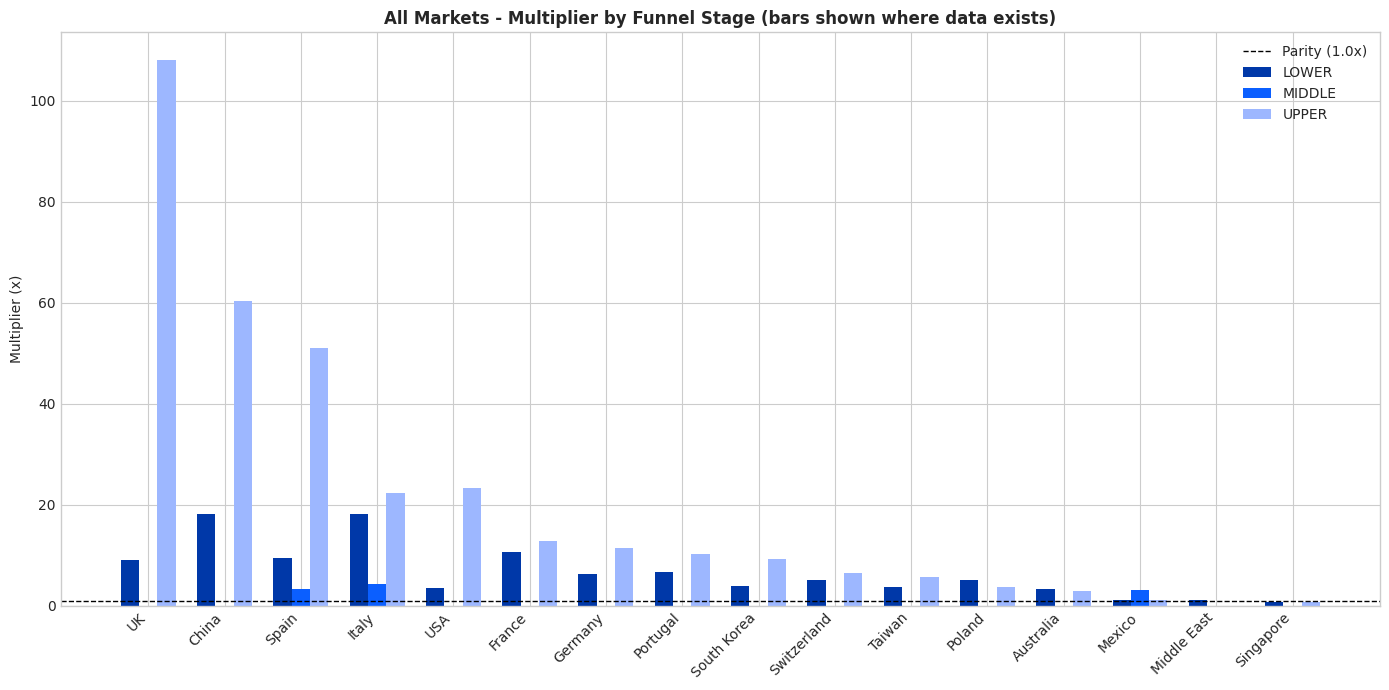

In [286]:
# Chart 2: all markets, bars shown only where stage data exists
market_pivot = market_stage.pivot_table(index='market', columns='funnel_stage', values='multiplier', aggfunc='mean').copy()

# Remove aggregate helper row if present
market_pivot = market_pivot[market_pivot.index != 'Client Total']

# Rank by mean of available stages (skip NaN), keep all markets
market_pivot['avg_mult_available'] = market_pivot[['LOWER', 'MIDDLE', 'UPPER']].mean(axis=1, skipna=True)
plot2 = market_pivot.sort_values('avg_mult_available', ascending=False).drop(columns=['avg_mult_available'])

x = np.arange(len(plot2.index))
width = 0.24

fig, ax = plt.subplots(figsize=(14, 7))
# keep NaN so bars appear only when stage exists
ax.bar(x - width, plot2['LOWER'], width, label='LOWER', color='#0038A8')
ax.bar(x,         plot2['MIDDLE'], width, label='MIDDLE', color='#0B5FFF')
ax.bar(x + width, plot2['UPPER'], width, label='UPPER', color='#9DB7FF')

ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Parity (1.0x)')
ax.set_xticks(x)
ax.set_xticklabels(plot2.index, rotation=45, ha='right')
ax.set_ylabel('Multiplier (x)')
ax.set_title('All Markets - Multiplier by Funnel Stage (bars shown where data exists)', fontsize=12, weight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

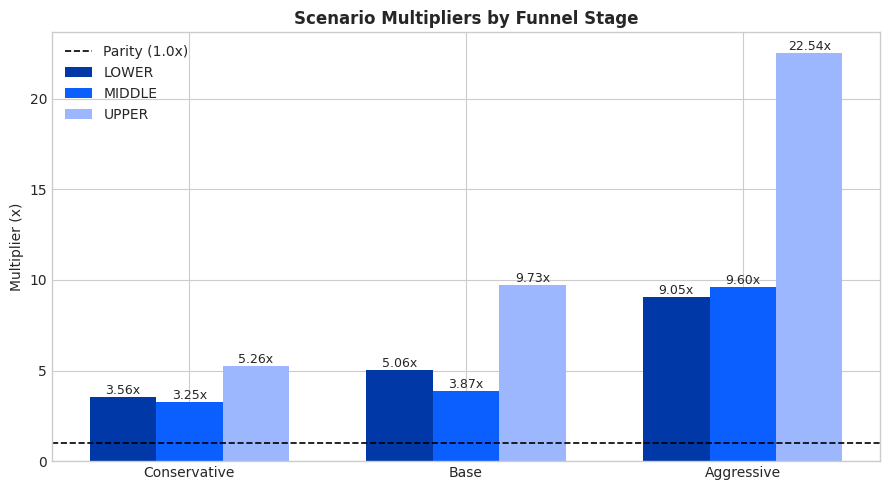

In [287]:
# Chart 3: scenario multipliers by funnel stage (3 bars per scenario)
plot3 = range_df.pivot(index='scenario', columns='funnel_stage', values='multiplier').loc[['Conservative', 'Base', 'Aggressive']]

x = np.arange(len(plot3.index))
width = 0.24

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, plot3['LOWER'], width, label='LOWER', color='#0038A8')
ax.bar(x,         plot3['MIDDLE'], width, label='MIDDLE', color='#0B5FFF')
ax.bar(x + width, plot3['UPPER'], width, label='UPPER', color='#9DB7FF')

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Parity (1.0x)')
ax.set_xticks(x)
ax.set_xticklabels(plot3.index)
ax.set_ylabel('Multiplier (x)')
ax.set_title('Scenario Multipliers by Funnel Stage', fontsize=12, weight='bold')
ax.legend(loc='upper left')

for i, scenario in enumerate(plot3.index):
    for j, stage in enumerate(['LOWER', 'MIDDLE', 'UPPER']):
        y = plot3.loc[scenario, stage]
        x_pos = i + (-width if stage == 'LOWER' else (0 if stage == 'MIDDLE' else width))
        ax.text(x_pos, y, f"{y:.2f}x", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Visual takeaway

- Chart 1 shows Porsche vs competitor benchmark split into **LOWER/MIDDLE/UPPER**.
- Chart 2 shows **by-market gaps** with three bars per market (one per funnel stage).
- Chart 3 shows **Conservative/Base/Aggressive** multipliers, again split into **LOWER/MIDDLE/UPPER**.


## Step 8 - Debs benchmark outputs (VWG named + premium anonymized)

This section answers the three requested outputs:
1. Comparative spend by market
2. Media channel split overall and by main market
3. Funnel stage split overall and by main market

In [288]:
# Build benchmark dataset from two sources:
# - Mappe1.xlsx: named VWG brands (Tier 1, 2024)
# - DS workbook: premium competitors (anonymized, auto sector)

MAPPE_FILE = BASE / 'Mappe1.xlsx'

# ---------- VWG named data ----------
v = pd.read_excel(MAPPE_FILE, sheet_name='2024', header=6)
v.columns = [str(c).strip() for c in v.columns]
v = v.rename(columns={
    'Brand': 'brand',
    'Market': 'market',
    'Media': 'media',
    'Sum of 2024 CY (EUR)': 'spend_eur'
})[['brand', 'market', 'media', 'spend_eur']]

for c in ['brand', 'market', 'media']:
    v[c] = v[c].astype(str).str.strip()
v['spend_eur'] = pd.to_numeric(v['spend_eur'], errors='coerce')
v = v[v['spend_eur'].notna() & (v['spend_eur'] > 0)].copy()

# keep Tier 1 rows, remove totals/helper rows
v = v[v['brand'].str.contains('Tier 1', case=False, na=False)].copy()
v = v[~v['brand'].str.contains('Total|Grand Total', case=False, na=False)].copy()
v = v[~v['market'].str.contains('Total', case=False, na=False)].copy()

v['brand_clean'] = v['brand'].str.replace(' - Tier 1', '', regex=False).str.strip()

# Porsche markets in VWG file
porsche_markets = sorted(v.loc[v['brand_clean'].str.upper() == 'PORSCHE', 'market'].unique())

# ---------- Premium anonymized data ----------
prem_raw = pd.read_excel(FILE, sheet_name='Detailed Data', header=3)
prem_raw.columns = [str(c).strip() for c in prem_raw.columns]

prem = prem_raw[['Client', 'Anonymised Client', 'Client Sector', 'Market', 'Deb Categories', '2025 Spend (EUR)']].copy()
prem.columns = ['client', 'anon_client', 'sector', 'market', 'deb_category', 'spend_eur']
for c in ['client', 'anon_client', 'sector', 'market', 'deb_category']:
    prem[c] = prem[c].astype(str).str.strip()
prem['spend_eur'] = pd.to_numeric(prem['spend_eur'], errors='coerce')
prem = prem[prem['spend_eur'].notna() & (prem['spend_eur'] > 0)].copy()

is_prem_porsche = (prem['client'].str.upper() == 'PORSCHE') | (prem['anon_client'].str.upper() == 'PORSCHE')
prem = prem[(~is_prem_porsche) & (prem['sector'].str.contains('auto', case=False, na=False))].copy()
prem = prem[prem['market'].isin(porsche_markets)].copy()

print('Porsche markets (VWG file):', len(porsche_markets))
print('Named VWG brands (Tier 1):', v['brand_clean'].nunique())
print('Anonymized premium rows:', len(prem))

Porsche markets (VWG file): 20
Named VWG brands (Tier 1): 9
Anonymized premium rows: 454


In [289]:
# 1) Comparative spend by market
porsche_mkt = (
    v[v['brand_clean'].str.upper() == 'PORSCHE']
    .groupby('market', as_index=False)['spend_eur'].sum()
    .rename(columns={'spend_eur': 'porsche_t1_2024'})
)

vwg_named_mkt = (
    v[v['brand_clean'].str.upper() != 'PORSCHE']
    .groupby('market', as_index=False)['spend_eur'].sum()
    .rename(columns={'spend_eur': 'vwg_named_t1_2024'})
)

premium_anon_mkt = (
    prem.groupby('market', as_index=False)['spend_eur'].sum()
    .rename(columns={'spend_eur': 'premium_anon_total'})
)

comparative_market_spend = (
    porsche_mkt
    .merge(vwg_named_mkt, on='market', how='left')
    .merge(premium_anon_mkt, on='market', how='left')
    .fillna(0)
    .sort_values('porsche_t1_2024', ascending=False)
)

main_markets = comparative_market_spend.head(10)['market'].tolist()
comparative_market_spend.head(10)

,market,porsche_t1_2024,vwg_named_t1_2024,premium_anon_total
19,USA,32848461.0,242261715.0,4.936339e+08
3,China,10800742.0,0.0,1.990871e+08
18,UK,4069785.0,117496477.0,1.512999e+08
2,Canada,2633829.0,20704700.0,3.951768e+07
5,Germany,2384298.0,162741064.0,1.494825e+08
8,Mexico,2171933.0,31400322.0,1.002060e+07
6,Italy,1919755.0,125679301.0,7.484220e+07
4,France,1865631.0,113398062.0,6.048880e+07
14,Spain,1521673.0,110428625.0,4.713907e+07
10,Poland,1488008.0,18851270.0,2.105766e+07


In [290]:
# 2) Media channel split overall and by main market

# benchmark universe = named VWG non-Porsche + premium anonymized
vwg_non = v[(v['brand_clean'].str.upper() != 'PORSCHE') & (v['market'].isin(porsche_markets))].copy()
vwg_non = vwg_non.rename(columns={'media': 'channel'})[['market', 'channel', 'spend_eur']]

prem_non = prem.rename(columns={'deb_category': 'channel'})[['market', 'channel', 'spend_eur']]
benchmark_channel = pd.concat([vwg_non, prem_non], ignore_index=True)

# simple harmonization
channel_replace = {
    'Dig. Video': 'Programmatic Video',
    'Video': 'Programmatic Video',
    'Display': 'Programmatic Display',
}
benchmark_channel['channel'] = benchmark_channel['channel'].replace(channel_replace)

media_split_overall = (
    benchmark_channel.groupby('channel', as_index=False)['spend_eur'].sum()
    .sort_values('spend_eur', ascending=False)
)
media_split_overall['share'] = media_split_overall['spend_eur'] / media_split_overall['spend_eur'].sum()

media_split_main = (
    benchmark_channel[benchmark_channel['market'].isin(main_markets)]
    .groupby(['market', 'channel'], as_index=False)['spend_eur'].sum()
)
main_totals = media_split_main.groupby('market', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'market_total'})
media_split_main = media_split_main.merge(main_totals, on='market', how='left')
media_split_main['share'] = media_split_main['spend_eur'] / media_split_main['market_total']

print('Overall channel split')
media_split_overall.head(12)

Overall channel split


,channel,spend_eur,share
11,TV,6.465151e+08,0.273494
1,Digital I/O,3.747704e+08,0.158538
10,Social,3.195518e+08,0.135179
9,Search,3.175258e+08,0.134322
7,Programmatic Video,1.726086e+08,0.073018
2,OOH,1.485858e+08,0.062856
6,Programmatic Display,1.393039e+08,0.058929
4,Other eg Sponsorship,6.628754e+07,0.028041
8,Radio,6.615169e+07,0.027984
5,Print,6.458589e+07,0.027322


In [291]:
# 3) Funnel stage split overall and by main market

channel_to_stage = {
    'Search': 'LOWER',
    'Paid Search': 'LOWER',
    'Social': 'MIDDLE',
    'Paid Social': 'MIDDLE',
    'Programmatic Display': 'MIDDLE',
    'Digital I/O': 'MIDDLE',
    'Display': 'MIDDLE',
    'Other': 'MIDDLE',
    'Programmatic Video': 'UPPER',
    'TV': 'UPPER',
    'Print': 'UPPER',
    'OOH': 'UPPER',
    'Radio': 'UPPER',
    'Cinema': 'UPPER',
    'Brand Sponsorship & Partnership': 'UPPER',
    'Connected TV (CTV)': 'UPPER',
}

benchmark_channel['funnel_stage'] = benchmark_channel['channel'].map(channel_to_stage).fillna('MIDDLE')

funnel_split_overall = benchmark_channel.groupby('funnel_stage', as_index=False)['spend_eur'].sum()
funnel_split_overall['share'] = funnel_split_overall['spend_eur'] / funnel_split_overall['spend_eur'].sum()

funnel_split_main = (
    benchmark_channel[benchmark_channel['market'].isin(main_markets)]
    .groupby(['market', 'funnel_stage'], as_index=False)['spend_eur'].sum()
)
main_funnel_totals = funnel_split_main.groupby('market', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'market_total'})
funnel_split_main = funnel_split_main.merge(main_funnel_totals, on='market', how='left')
funnel_split_main['share'] = funnel_split_main['spend_eur'] / funnel_split_main['market_total']

print('Funnel split overall')
funnel_split_overall.sort_values('spend_eur', ascending=False)

Funnel split overall


,funnel_stage,spend_eur,share
2,UPPER,1.112944e+09,0.470806
1,MIDDLE,9.334428e+08,0.394872
0,LOWER,3.175258e+08,0.134322


In [ ]:
# Compact by-main-market summaries (top 3 channels + full funnel shares)

media_main_top3 = (
    media_split_main.sort_values(['market', 'spend_eur'], ascending=[True, False])
    .groupby('market', as_index=False)
    .head(3)
    .copy()
)
media_main_top3['share_pct'] = (media_main_top3['share'] * 100).round(1)

funnel_main_pct = funnel_split_main.copy()
funnel_main_pct['share_pct'] = (funnel_main_pct['share'] * 100).round(1)

print('Top 3 channels by main market')
media_main_top3[['market', 'channel', 'share_pct']]

print('\nFunnel split by main market')
funnel_main_pct[['market', 'funnel_stage', 'share_pct']].sort_values(['market', 'funnel_stage'])

Top 3 channels by main market

Funnel split by main market


,market,funnel_stage,share_pct
0,Canada,LOWER,22.0
1,Canada,MIDDLE,33.7
2,Canada,UPPER,44.4
3,China,LOWER,3.8
4,China,MIDDLE,78.0
5,China,UPPER,18.2
6,France,LOWER,10.6
7,France,MIDDLE,33.8
8,France,UPPER,55.6
9,Germany,LOWER,25.1


## Step 8b - Individual VWG brand comparisons (not aggregated)

This section keeps VWG brands separate and answers the same benchmark views with brand-level detail.

In [ ]:
# 1) Comparative spend by market - individual VWG brands
vwg_named_brand_market = (
    v[v['brand_clean'].str.upper() != 'PORSCHE']
    .groupby(['market', 'brand_clean'], as_index=False)['spend_eur'].sum()
    .rename(columns={'spend_eur': 'brand_spend_eur'})
)

# market-level context columns
market_context = comparative_market_spend[['market', 'porsche_t1_2024', 'premium_anon_total']].copy()
brand_market_comparison = vwg_named_brand_market.merge(market_context, on='market', how='left')

# optional pivot view (brands as columns)
brand_market_pivot = brand_market_comparison.pivot_table(
    index='market',
    columns='brand_clean',
    values='brand_spend_eur',
    aggfunc='sum'
).fillna(0)

brand_market_comparison.sort_values(['market', 'brand_spend_eur'], ascending=[True, False]).head(30)

,market,brand_clean,brand_spend_eur,porsche_t1_2024,premium_anon_total
2,Argentina,VW Brand,2691823.0,NaN,NaN
1,Argentina,LCV,2344049.0,NaN,NaN
0,Argentina,Audi,459816.0,NaN,NaN
3,Australia,Audi,12352931.0,1336538.0,4.095135e+07
7,Australia,VW Brand,9308084.0,1336538.0,4.095135e+07
5,Australia,LCV,6397449.0,1336538.0,4.095135e+07
4,Australia,CUPRA,6026105.0,1336538.0,4.095135e+07
6,Australia,SKODA,4673186.0,1336538.0,4.095135e+07
8,Austria,MAN,235486.0,NaN,NaN
9,Bentley Central Campaigns,Bentley,12251163.0,NaN,NaN


In [ ]:
# 2) Media channel split overall and by main market - by individual VWG brand
vwg_brand_channel_overall = (
    v[(v['brand_clean'].str.upper() != 'PORSCHE') & (v['market'].isin(porsche_markets))]
    .groupby(['brand_clean', 'media'], as_index=False)['spend_eur'].sum()
)

brand_totals = vwg_brand_channel_overall.groupby('brand_clean', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'brand_total'})
vwg_brand_channel_overall = vwg_brand_channel_overall.merge(brand_totals, on='brand_clean', how='left')
vwg_brand_channel_overall['share_within_brand'] = vwg_brand_channel_overall['spend_eur'] / vwg_brand_channel_overall['brand_total']

vwg_brand_channel_main = (
    v[(v['brand_clean'].str.upper() != 'PORSCHE') & (v['market'].isin(main_markets))]
    .groupby(['market', 'brand_clean', 'media'], as_index=False)['spend_eur'].sum()
)
mb_totals = vwg_brand_channel_main.groupby(['market', 'brand_clean'], as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'mb_total'})
vwg_brand_channel_main = vwg_brand_channel_main.merge(mb_totals, on=['market', 'brand_clean'], how='left')
vwg_brand_channel_main['share_within_market_brand'] = vwg_brand_channel_main['spend_eur'] / vwg_brand_channel_main['mb_total']

print('Overall channel split by VWG brand')
vwg_brand_channel_overall.sort_values(['brand_clean', 'spend_eur'], ascending=[True, False]).head(30)

Overall channel split by VWG brand


,brand_clean,media,spend_eur,brand_total,share_within_brand
10,Audi,TV,72631277.0,248826341.0,0.291895
8,Audi,Search,33251221.0,248826341.0,0.133632
1,Audi,Digital I/O,30253070.0,248826341.0,0.121583
6,Audi,Programmatic Video,29429405.0,248826341.0,0.118273
9,Audi,Social,22508865.0,248826341.0,0.090460
2,Audi,OOH,16195569.0,248826341.0,0.065088
5,Audi,Programmatic Display,14391905.0,248826341.0,0.057839
3,Audi,Other eg Sponsorship,12546275.0,248826341.0,0.050422
7,Audi,Radio,7609223.0,248826341.0,0.030580
4,Audi,Print,6938601.0,248826341.0,0.027885


In [ ]:
# 3) Funnel stage split overall and by main market - by individual VWG brand

media_to_stage_named = {
    'Search': 'LOWER',
    'Paid Search': 'LOWER',
    'Social': 'MIDDLE',
    'Paid Social': 'MIDDLE',
    'Programmatic Display': 'MIDDLE',
    'Digital I/O': 'MIDDLE',
    'Display': 'MIDDLE',
    'Other': 'MIDDLE',
    'Programmatic Video': 'UPPER',
    'Dig. Video': 'UPPER',
    'Video': 'UPPER',
    'TV': 'UPPER',
    'Print': 'UPPER',
    'OOH': 'UPPER',
    'Radio': 'UPPER',
    'Cinema': 'UPPER',
    'Brand Sponsorship & Partnership': 'UPPER',
    'Connected TV (CTV)': 'UPPER',
}

v_named = v[(v['brand_clean'].str.upper() != 'PORSCHE') & (v['market'].isin(porsche_markets))].copy()
v_named['funnel_stage'] = v_named['media'].map(media_to_stage_named).fillna('MIDDLE')

vwg_brand_funnel_overall = v_named.groupby(['brand_clean', 'funnel_stage'], as_index=False)['spend_eur'].sum()
bf_totals = vwg_brand_funnel_overall.groupby('brand_clean', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'brand_total'})
vwg_brand_funnel_overall = vwg_brand_funnel_overall.merge(bf_totals, on='brand_clean', how='left')
vwg_brand_funnel_overall['share_within_brand'] = vwg_brand_funnel_overall['spend_eur'] / vwg_brand_funnel_overall['brand_total']

v_named_main = v_named[v_named['market'].isin(main_markets)].copy()
vwg_brand_funnel_main = v_named_main.groupby(['market', 'brand_clean', 'funnel_stage'], as_index=False)['spend_eur'].sum()
mbf_totals = vwg_brand_funnel_main.groupby(['market', 'brand_clean'], as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'mb_total'})
vwg_brand_funnel_main = vwg_brand_funnel_main.merge(mbf_totals, on=['market', 'brand_clean'], how='left')
vwg_brand_funnel_main['share_within_market_brand'] = vwg_brand_funnel_main['spend_eur'] / vwg_brand_funnel_main['mb_total']

print('Overall funnel split by VWG brand')
vwg_brand_funnel_overall.sort_values(['brand_clean', 'funnel_stage'])

Overall funnel split by VWG brand


,brand_clean,funnel_stage,spend_eur,brand_total,share_within_brand
0,Audi,LOWER,33251221.0,248826341.0,0.133632
1,Audi,MIDDLE,80106933.0,248826341.0,0.321939
2,Audi,UPPER,135468187.0,248826341.0,0.544429
3,CUPRA,LOWER,14804646.0,114679115.0,0.129096
4,CUPRA,MIDDLE,44577669.0,114679115.0,0.388717
5,CUPRA,UPPER,55296800.0,114679115.0,0.482187
6,LCV,LOWER,5293548.0,48046192.0,0.110176
7,LCV,MIDDLE,24319527.0,48046192.0,0.506170
8,LCV,UPPER,18433117.0,48046192.0,0.383654
9,MAN,LOWER,352590.0,6134666.0,0.057475


In [296]:
# Compact summaries to copy to slide/email

print('--- Comparative spend by market (brand-level, first rows) ---')
display(
    brand_market_comparison
    .sort_values(['market', 'brand_spend_eur'], ascending=[True, False])
    .head(40)
)

print('--- Channel split by VWG brand (overall, top 5 channels per brand) ---')
display(
    vwg_brand_channel_overall
    .sort_values(['brand_clean', 'spend_eur'], ascending=[True, False])
    .groupby('brand_clean', as_index=False)
    .head(5)
)

print('--- Funnel split by VWG brand (overall) ---')
display(
    vwg_brand_funnel_overall
    .sort_values(['brand_clean', 'funnel_stage'])
)

print('--- Funnel split by VWG brand and main market (sample) ---')
display(
    vwg_brand_funnel_main
    .sort_values(['market', 'brand_clean', 'funnel_stage'])
    .head(60)
)

--- Comparative spend by market (brand-level, first rows) ---


,market,brand_clean,brand_spend_eur,porsche_t1_2024,premium_anon_total
2,Argentina,VW Brand,2691823.0,NaN,NaN
1,Argentina,LCV,2344049.0,NaN,NaN
0,Argentina,Audi,459816.0,NaN,NaN
3,Australia,Audi,12352931.0,1336538.0,4.095135e+07
7,Australia,VW Brand,9308084.0,1336538.0,4.095135e+07
5,Australia,LCV,6397449.0,1336538.0,4.095135e+07
4,Australia,CUPRA,6026105.0,1336538.0,4.095135e+07
6,Australia,SKODA,4673186.0,1336538.0,4.095135e+07
8,Austria,MAN,235486.0,NaN,NaN
9,Bentley Central Campaigns,Bentley,12251163.0,NaN,NaN


--- Channel split by VWG brand (overall, top 5 channels per brand) ---


,brand_clean,media,spend_eur,brand_total,share_within_brand
10,Audi,TV,72631277.0,248826341.0,0.291895
8,Audi,Search,33251221.0,248826341.0,0.133632
1,Audi,Digital I/O,30253070.0,248826341.0,0.121583
6,Audi,Programmatic Video,29429405.0,248826341.0,0.118273
9,Audi,Social,22508865.0,248826341.0,0.090460
22,CUPRA,TV,41397629.0,114679115.0,0.360987
13,CUPRA,Digital I/O,16791307.0,114679115.0,0.146420
20,CUPRA,Search,14804646.0,114679115.0,0.129096
21,CUPRA,Social,12410272.0,114679115.0,0.108217
15,CUPRA,Other eg Sponsorship,10186082.0,114679115.0,0.088822


--- Funnel split by VWG brand (overall) ---


,brand_clean,funnel_stage,spend_eur,brand_total,share_within_brand
0,Audi,LOWER,33251221.0,248826341.0,0.133632
1,Audi,MIDDLE,80106933.0,248826341.0,0.321939
2,Audi,UPPER,135468187.0,248826341.0,0.544429
3,CUPRA,LOWER,14804646.0,114679115.0,0.129096
4,CUPRA,MIDDLE,44577669.0,114679115.0,0.388717
5,CUPRA,UPPER,55296800.0,114679115.0,0.482187
6,LCV,LOWER,5293548.0,48046192.0,0.110176
7,LCV,MIDDLE,24319527.0,48046192.0,0.506170
8,LCV,UPPER,18433117.0,48046192.0,0.383654
9,MAN,LOWER,352590.0,6134666.0,0.057475


--- Funnel split by VWG brand and main market (sample) ---


,market,brand_clean,funnel_stage,spend_eur,mb_total,share_within_market_brand
0,Canada,Audi,LOWER,2000174.0,9695647.0,0.206296
1,Canada,Audi,MIDDLE,3348732.0,9695647.0,0.345385
2,Canada,Audi,UPPER,4346741.0,9695647.0,0.448319
3,Canada,VW Brand,LOWER,1585383.0,11009053.0,0.144007
4,Canada,VW Brand,MIDDLE,1797078.0,11009053.0,0.163236
5,Canada,VW Brand,UPPER,7626592.0,11009053.0,0.692756
6,France,Audi,LOWER,2355650.0,21894095.0,0.107593
7,France,Audi,MIDDLE,8590035.0,21894095.0,0.392345
8,France,Audi,UPPER,10948410.0,21894095.0,0.500062
9,France,CUPRA,LOWER,1519065.0,17393961.0,0.087333


## Step 8c - Charts for Debs brief (lines 34-36)

Charts in this section answer exactly:
1. Comparative spend by market
2. Media channel split overall and by main market
3. Funnel stage split overall and by main market

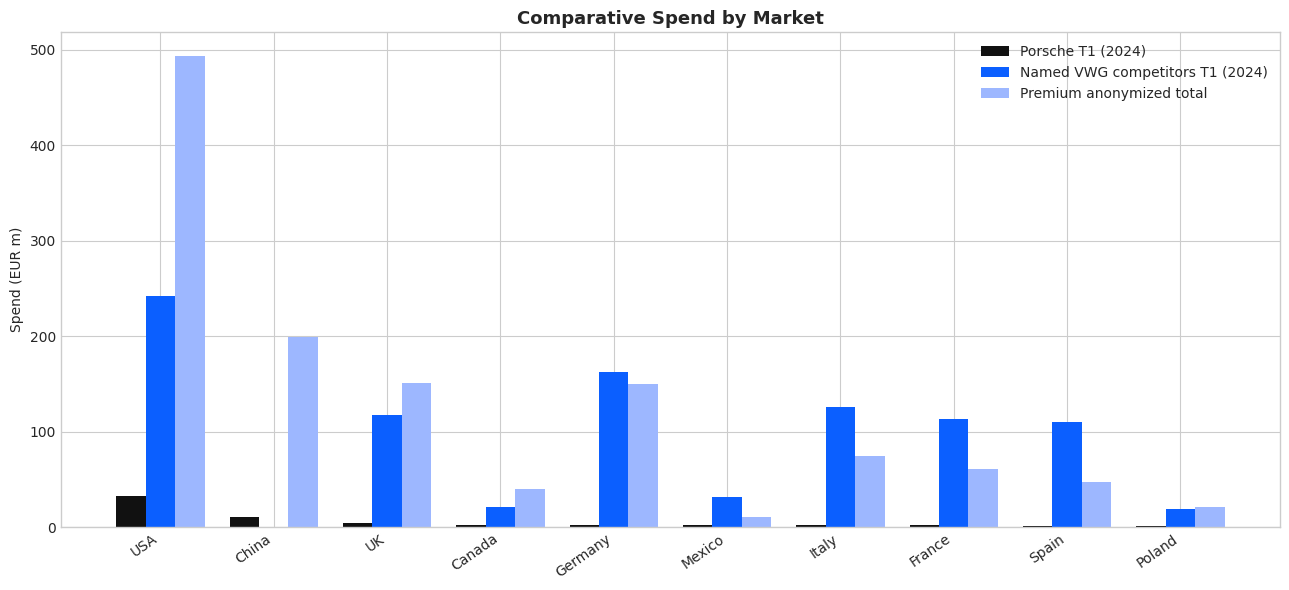

In [297]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# 1) Comparative spend by market (top 10 Porsche markets)
plot_market = comparative_market_spend.head(10).copy()

x = np.arange(len(plot_market))
width = 0.26

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width, plot_market['porsche_t1_2024'] / 1e6, width, label='Porsche T1 (2024)', color='#111111')
ax.bar(x,         plot_market['vwg_named_t1_2024'] / 1e6, width, label='Named VWG competitors T1 (2024)', color='#0B5FFF')
ax.bar(x + width, plot_market['premium_anon_total'] / 1e6, width, label='Premium anonymized total', color='#9DB7FF')

ax.set_xticks(x)
ax.set_xticklabels(plot_market['market'], rotation=35, ha='right')
ax.set_ylabel('Spend (EUR m)')
ax.set_title('Comparative Spend by Market', fontsize=13, weight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

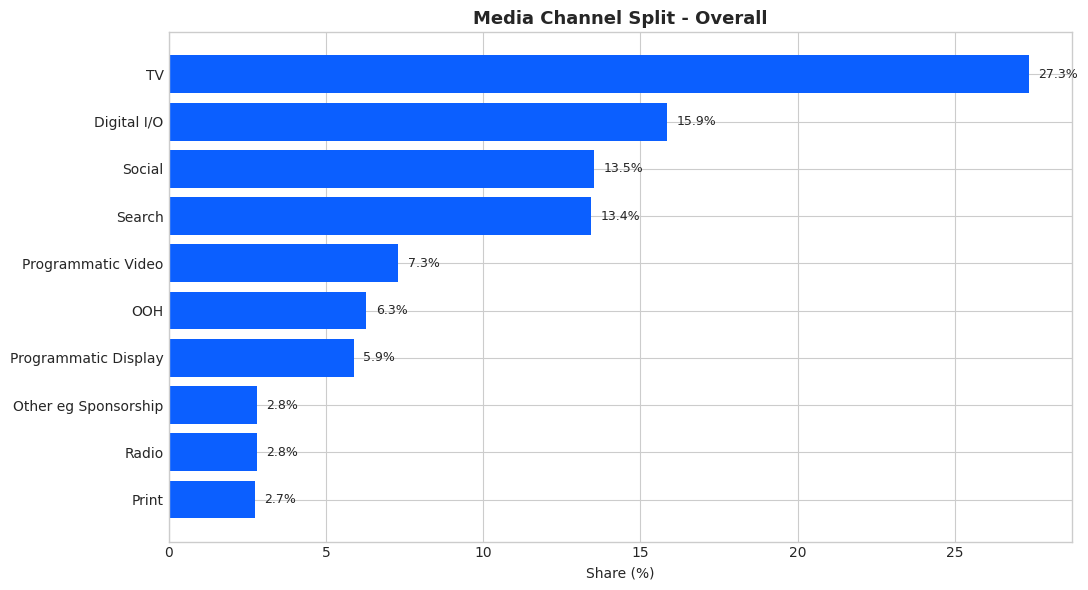

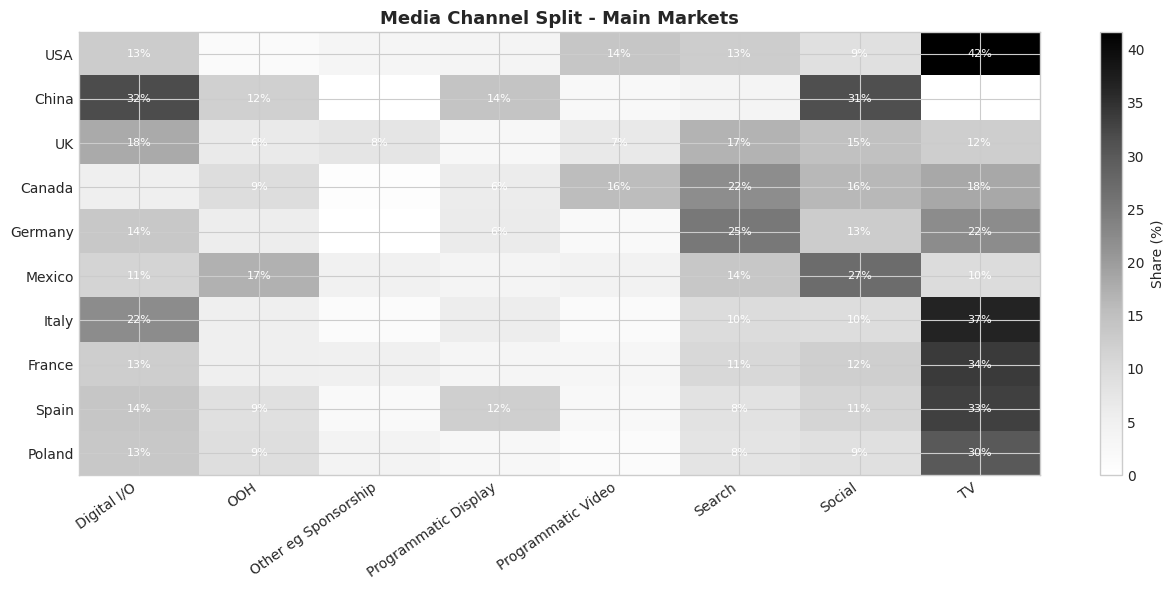

In [298]:
# 2a) Media channel split overall
plot_channel_overall = media_split_overall.copy().head(10)
plot_channel_overall['share_pct'] = plot_channel_overall['share'] * 100

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(plot_channel_overall['channel'][::-1], plot_channel_overall['share_pct'][::-1], color='#0B5FFF')

ax.set_xlabel('Share (%)')
ax.set_title('Media Channel Split - Overall', fontsize=13, weight='bold')

for i, v in enumerate(plot_channel_overall['share_pct'][::-1]):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 2b) Media channel split by main market (heatmap-like matrix)
plot_channel_main = media_split_main.copy()
plot_channel_main['share_pct'] = plot_channel_main['share'] * 100

# keep top channels overall for readability
top_channels = media_split_overall.head(8)['channel'].tolist()
plot_channel_main = plot_channel_main[plot_channel_main['channel'].isin(top_channels)].copy()

channel_matrix = plot_channel_main.pivot_table(index='market', columns='channel', values='share_pct', aggfunc='sum').fillna(0)
channel_matrix = channel_matrix.reindex(main_markets).dropna(how='all')

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(channel_matrix.values, aspect='auto')

ax.set_xticks(np.arange(len(channel_matrix.columns)))
ax.set_xticklabels(channel_matrix.columns, rotation=35, ha='right')
ax.set_yticks(np.arange(len(channel_matrix.index)))
ax.set_yticklabels(channel_matrix.index)
ax.set_title('Media Channel Split - Main Markets', fontsize=13, weight='bold')

# annotate
for i in range(channel_matrix.shape[0]):
    for j in range(channel_matrix.shape[1]):
        val = channel_matrix.values[i, j]
        if val >= 6:
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8, color='white')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Share (%)')

plt.tight_layout()
plt.show()

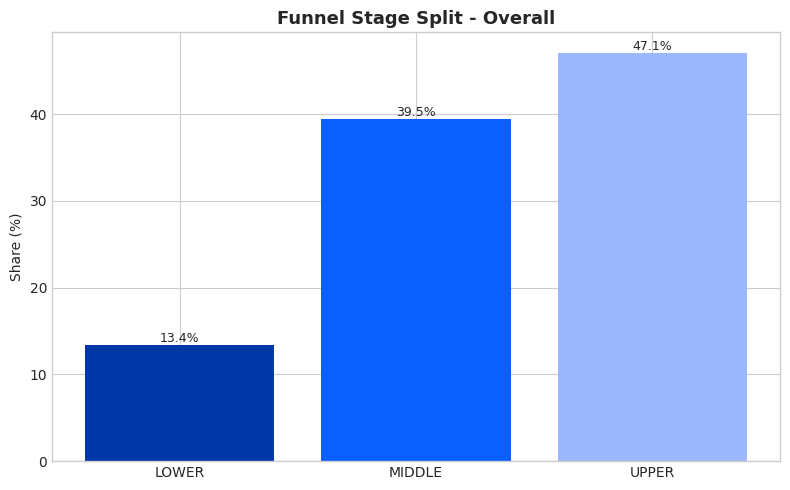

/tmp/ipykernel_54030/3424551241.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  funnel_matrix = plot_funnel_main.pivot_table(index='market', columns='funnel_stage', values='share_pct', aggfunc='sum').fillna(0)


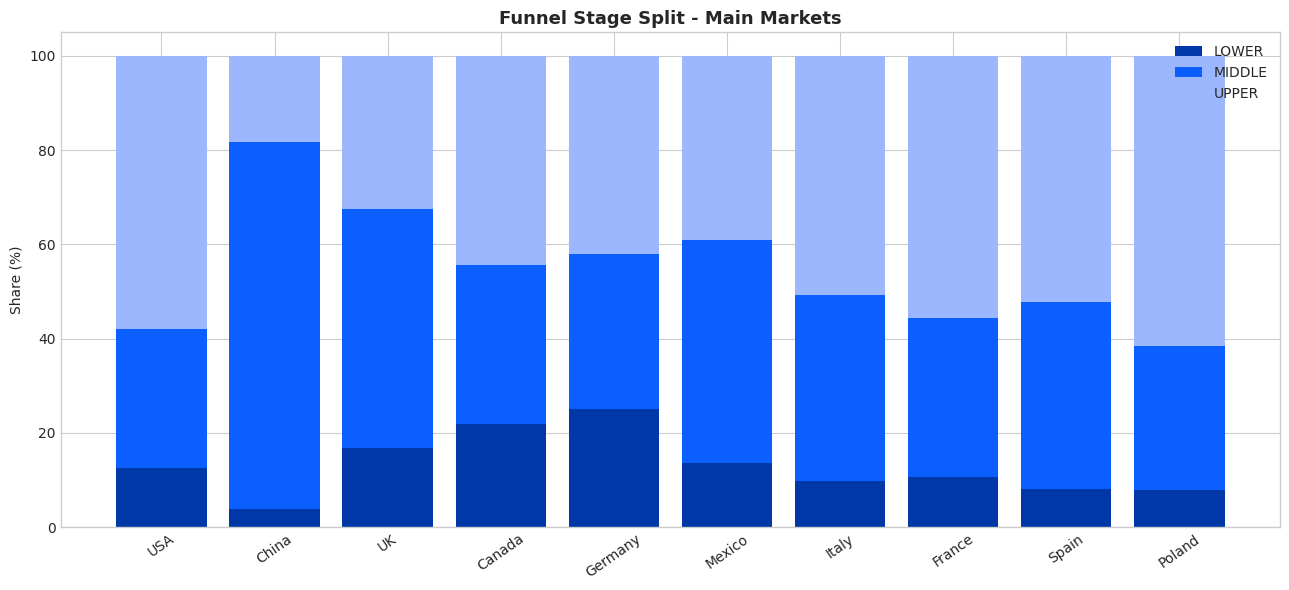

In [299]:
# 3a) Funnel stage split overall
plot_funnel_overall = funnel_split_overall.copy()
plot_funnel_overall['share_pct'] = plot_funnel_overall['share'] * 100
stage_order = ['LOWER', 'MIDDLE', 'UPPER']
plot_funnel_overall['funnel_stage'] = pd.Categorical(plot_funnel_overall['funnel_stage'], categories=stage_order, ordered=True)
plot_funnel_overall = plot_funnel_overall.sort_values('funnel_stage')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#0038A8', '#0B5FFF', '#9DB7FF']
bars = ax.bar(plot_funnel_overall['funnel_stage'], plot_funnel_overall['share_pct'], color=colors)

ax.set_ylabel('Share (%)')
ax.set_title('Funnel Stage Split - Overall', fontsize=13, weight='bold')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 3b) Funnel stage split by main market (stacked)
plot_funnel_main = funnel_split_main.copy()
plot_funnel_main['share_pct'] = plot_funnel_main['share'] * 100
plot_funnel_main['funnel_stage'] = pd.Categorical(plot_funnel_main['funnel_stage'], categories=stage_order, ordered=True)

funnel_matrix = plot_funnel_main.pivot_table(index='market', columns='funnel_stage', values='share_pct', aggfunc='sum').fillna(0)
funnel_matrix = funnel_matrix.reindex(main_markets).dropna(how='all')

fig, ax = plt.subplots(figsize=(13, 6))
bottom = np.zeros(len(funnel_matrix))
for stage, color in zip(stage_order, colors):
    vals = funnel_matrix[stage].values if stage in funnel_matrix.columns else np.zeros(len(funnel_matrix))
    ax.bar(funnel_matrix.index, vals, bottom=bottom, label=stage, color=color)
    bottom += vals

ax.set_ylabel('Share (%)')
ax.set_title('Funnel Stage Split - Main Markets', fontsize=13, weight='bold')
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

## Step 8d - VW-only multipliers (plots)

This section uses `Mappe1.xlsx` only (Tier 1) and shows where Porsche stands vs named VWG competitors.

Multiplier definition:
`multiplier = avg VWG competitor brand spend / Porsche spend`

In [ ]:
# Build VW-only multiplier tables from Mappe1 (Tier 1)
vw = pd.read_excel(MAPPE_FILE, sheet_name='2024', header=6)
vw.columns = [str(c).strip() for c in vw.columns]
vw = vw.rename(columns={
    'Brand': 'brand_tier_raw',
    'Market': 'market',
    'Media': 'media',
    'Sum of 2024 CY (EUR)': 'spend_eur'
})[['brand_tier_raw', 'market', 'media', 'spend_eur']]

for c in ['brand_tier_raw', 'market', 'media']:
    vw[c] = vw[c].astype(str).str.strip()
vw['spend_eur'] = pd.to_numeric(vw['spend_eur'], errors='coerce')
vw = vw[vw['spend_eur'].notna() & (vw['spend_eur'] > 0)].copy()

# Split column A into explicit brand and tier columns
split = vw['brand_tier_raw'].str.extract(r'^(?P<brand>.*?)\s*-\s*Tier\s*(?P<tier>\d+)$')
vw['brand_clean'] = split['brand'].str.strip()
vw['tier'] = pd.to_numeric(split['tier'], errors='coerce')

# Keep only valid parsed rows, Tier 1, and remove helper totals rows/markets
vw = vw[vw['brand_clean'].notna() & vw['tier'].notna()].copy()
vw = vw[vw['tier'] == 1].copy()
vw = vw[~vw['brand_tier_raw'].str.contains('Total|Grand Total', case=False, na=False)].copy()
vw = vw[~vw['market'].str.contains('Total', case=False, na=False)].copy()

# scope: markets where Porsche exists
vw_markets = sorted(vw.loc[vw['brand_clean'].str.upper() == 'PORSCHE', 'market'].unique())
vw = vw[vw['market'].isin(vw_markets)].copy()

vw_p = vw[vw['brand_clean'].str.upper() == 'PORSCHE'].copy()
vw_c = vw[vw['brand_clean'].str.upper() != 'PORSCHE'].copy()


def compute_multiplier(df_p, df_c, keys):
    p_sum = df_p.groupby(keys, as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'porsche_spend'})
    c_brand = df_c.groupby(keys + ['brand_clean'], as_index=False)['spend_eur'].sum()
    c_avg = c_brand.groupby(keys, as_index=False)['spend_eur'].mean().rename(columns={'spend_eur': 'comp_avg_brand_spend'})
    out = p_sum.merge(c_avg, on=keys, how='inner')
    out['multiplier'] = out['comp_avg_brand_spend'] / out['porsche_spend']
    return out

# 1) market multipliers
vw_market_mult = compute_multiplier(vw_p, vw_c, ['market']).sort_values('porsche_spend', ascending=False)
# main markets = 5 biggest Porsche markets
vw_main_markets = vw_market_mult.head(5)['market'].tolist()

# 2) channel multipliers
vw_channel_mult_overall = compute_multiplier(vw_p, vw_c, ['media']).sort_values('multiplier', ascending=False)
vw_channel_mult_main = compute_multiplier(
    vw_p[vw_p['market'].isin(vw_main_markets)],
    vw_c[vw_c['market'].isin(vw_main_markets)],
    ['market', 'media']
)

# 3) funnel multipliers (channel->funnel mapping)
stage_map = {
    'Search': 'LOWER',
    'Social': 'MIDDLE', 'Display': 'MIDDLE', 'Digital I/O': 'MIDDLE', 'Other': 'MIDDLE',
    'Dig. Video': 'UPPER', 'Video': 'UPPER', 'Programmatic Video': 'UPPER',
    'TV': 'UPPER', 'Print': 'UPPER', 'OOH': 'UPPER', 'Radio': 'UPPER', 'Cinema': 'UPPER',
}
vw_p2 = vw_p.copy()
vw_c2 = vw_c.copy()
vw_p2['funnel_stage'] = vw_p2['media'].map(stage_map).fillna('MIDDLE')
vw_c2['funnel_stage'] = vw_c2['media'].map(stage_map).fillna('MIDDLE')

vw_funnel_mult_overall = compute_multiplier(vw_p2, vw_c2, ['funnel_stage'])
vw_funnel_mult_main = compute_multiplier(
    vw_p2[vw_p2['market'].isin(vw_main_markets)],
    vw_c2[vw_c2['market'].isin(vw_main_markets)],
    ['market', 'funnel_stage']
)

vw_market_mult.head()

,market,porsche_spend,comp_avg_brand_spend,multiplier
15,USA,32848461.0,1.211309e+08,3.687566
14,UK,4069785.0,1.958275e+07,4.811740
1,Canada,2633829.0,1.035235e+07,3.930532
3,Germany,2384298.0,2.324872e+07,9.750762
5,Mexico,2171933.0,6.280064e+06,2.891463


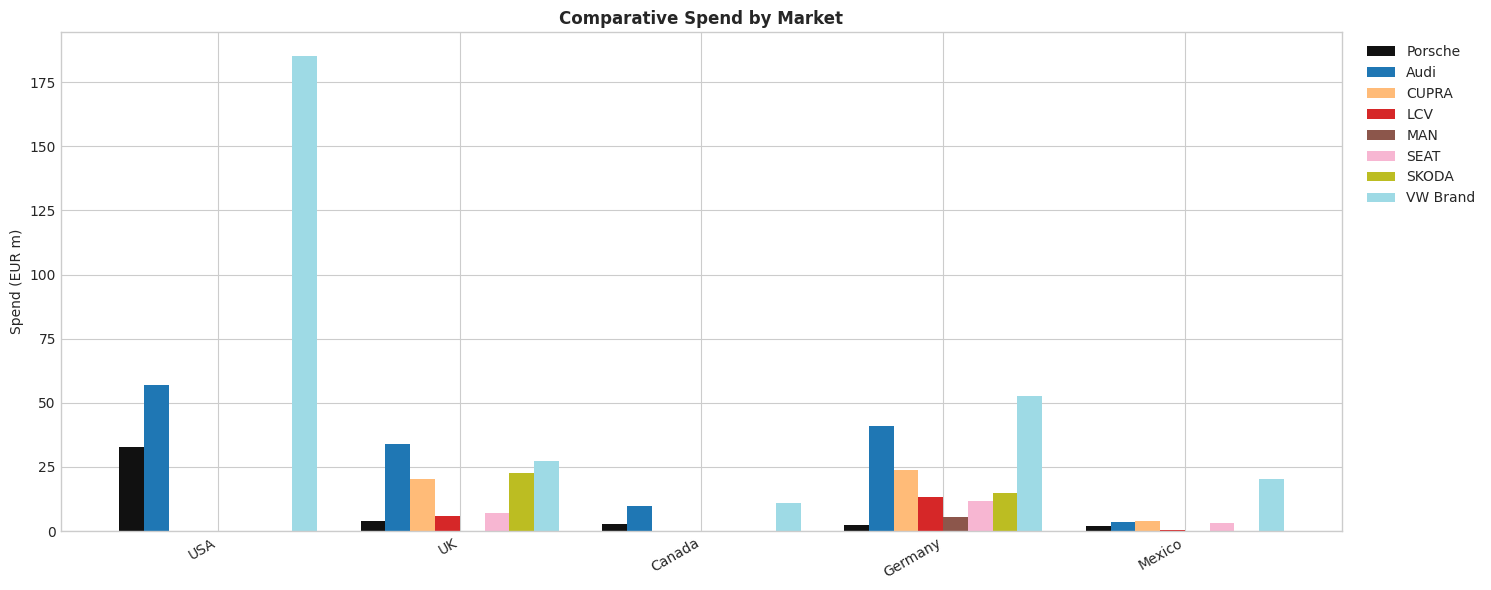

In [301]:
# Plot 1 - Comparative spend by market (individual VW brands vs Porsche)

# Porsche market spend
p_market = (
    vw_p[vw_p['market'].isin(vw_main_markets)]
    .groupby('market', as_index=False)['spend_eur'].sum()
    .rename(columns={'spend_eur': 'porsche_spend'})
)

# Individual VW brand spend by market
c_market_brand = (
    vw_c[vw_c['market'].isin(vw_main_markets)]
    .groupby(['market', 'brand_clean'], as_index=False)['spend_eur'].sum()
)

# Build matrix: Porsche + each brand as separate columns
market_brand_plot = c_market_brand.pivot_table(index='market', columns='brand_clean', values='spend_eur', aggfunc='sum').fillna(0)
market_brand_plot = market_brand_plot.merge(p_market.set_index('market'), left_index=True, right_index=True, how='left').fillna(0)
market_brand_plot = market_brand_plot.reindex(vw_main_markets)

# Put Porsche first, then brands
brand_cols = [c for c in market_brand_plot.columns if c != 'porsche_spend']
plot_cols = ['porsche_spend'] + brand_cols
plot_df = market_brand_plot[plot_cols].copy() / 1e6  # EUR m

x = np.arange(len(plot_df.index))
n_series = len(plot_cols)
width = min(0.82 / n_series, 0.12)

fig, ax = plt.subplots(figsize=(15, 6))
colors = ['#111111'] + list(plt.cm.tab20(np.linspace(0, 1, max(n_series - 1, 1))))

for i, col in enumerate(plot_cols):
    offset = (i - (n_series - 1) / 2) * width
    label = 'Porsche' if col == 'porsche_spend' else col
    ax.bar(x + offset, plot_df[col].values, width, label=label, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha='right')
ax.set_ylabel('Spend (EUR m)')
ax.set_title('Comparative Spend by Market', fontsize=12, weight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout()
plt.show()

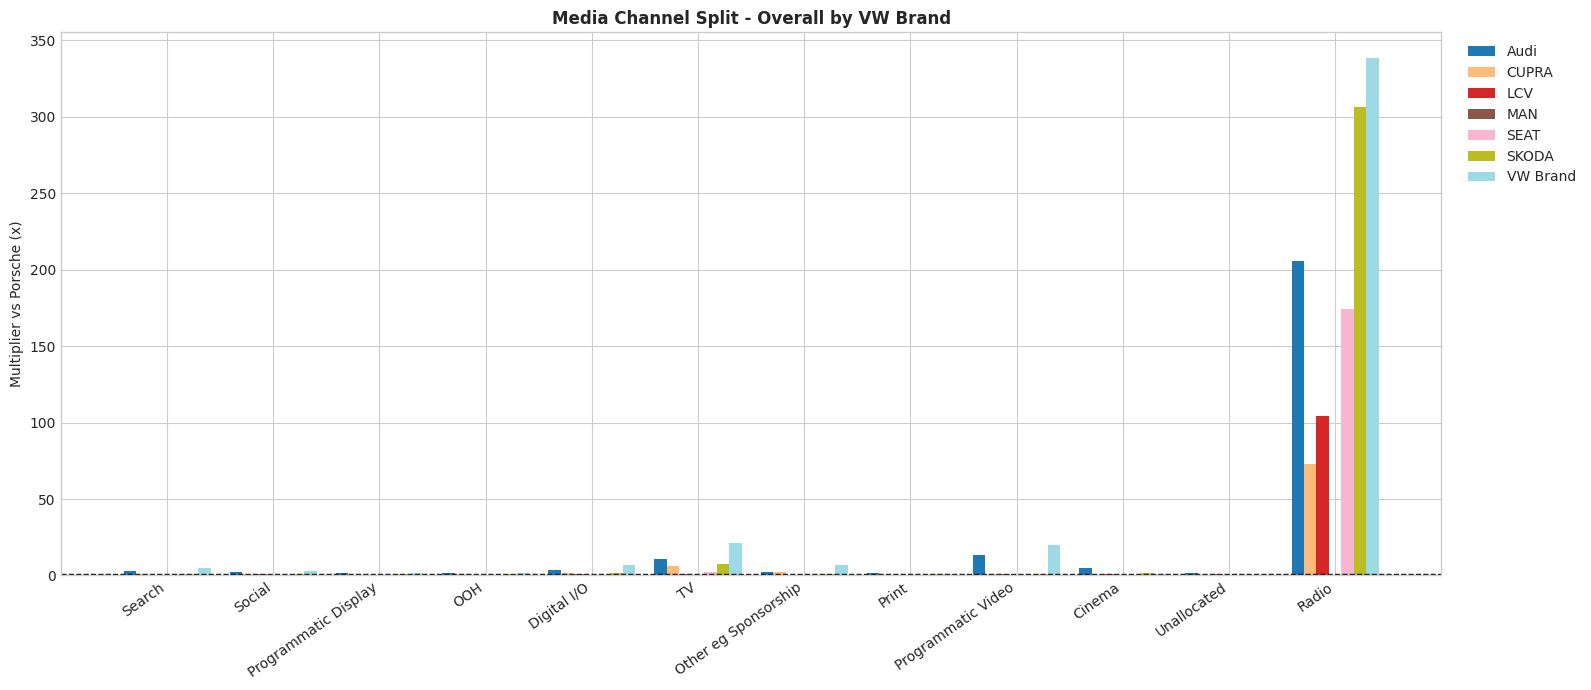

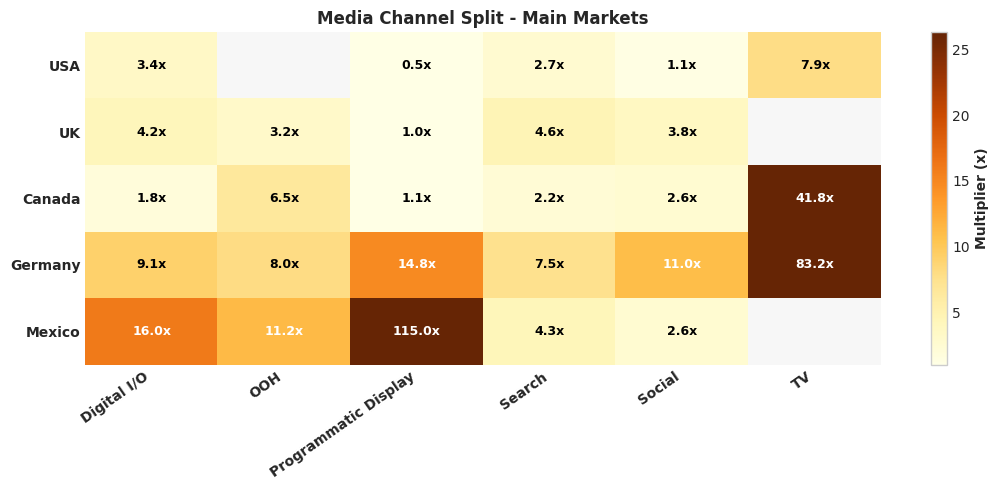

In [302]:
# Plot 2 - Media channel split overall and by main market

# 2a overall channel multipliers by brand (all VW brands)
p_channel = vw_p.groupby('media', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'porsche_spend'})
c_brand_channel = vw_c.groupby(['brand_clean', 'media'], as_index=False)['spend_eur'].sum()
brand_channel_mult = c_brand_channel.merge(p_channel, on='media', how='inner')
brand_channel_mult['multiplier'] = brand_channel_mult['spend_eur'] / brand_channel_mult['porsche_spend']

channel_order = p_channel.sort_values('porsche_spend', ascending=False)['media'].tolist()
plot_df = brand_channel_mult.pivot_table(index='media', columns='brand_clean', values='multiplier', aggfunc='mean').reindex(channel_order)
all_brands = list(plot_df.columns)

x = np.arange(len(plot_df.index))
n_brands = max(len(all_brands), 1)
width = min(0.82 / n_brands, 0.12)
colors = plt.cm.tab20(np.linspace(0, 1, n_brands))

fig, ax = plt.subplots(figsize=(16, 7))
for i, brand in enumerate(all_brands):
    vals = plot_df[brand].values if brand in plot_df.columns else np.zeros(len(plot_df))
    offset = (i - (n_brands - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=brand, color=colors[i])

ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=35, ha='right')
ax.set_ylabel('Multiplier vs Porsche (x)')
ax.set_title('Media Channel Split - Overall by VW Brand', fontsize=12, weight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout()
plt.show()

# 2b heatmap (kept aggregated by request)
tmp = vw_channel_mult_main.copy()
top_channels = (
    vw_channel_mult_overall.sort_values('porsche_spend', ascending=False)
    .head(6)['media'].tolist()
)
tmp = tmp[tmp['media'].isin(top_channels)]
ch_mat = tmp.pivot_table(index='market', columns='media', values='multiplier', aggfunc='mean').fillna(np.nan)
ch_mat = ch_mat.reindex(vw_main_markets).dropna(how='all')

color_mat = ch_mat.copy()
vmin = np.nanpercentile(color_mat.values, 5)
vmax = np.nanpercentile(color_mat.values, 90)
color_mat = color_mat.clip(lower=vmin, upper=vmax)

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
cmap = plt.cm.YlOrBr.copy()
cmap.set_bad('#f7f7f7')
im = ax.imshow(color_mat.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)

ax.set_xticks(np.arange(len(ch_mat.columns)))
ax.set_xticklabels(ch_mat.columns, rotation=35, ha='right', fontweight='bold')
ax.set_yticks(np.arange(len(ch_mat.index)))
ax.set_yticklabels(ch_mat.index, fontweight='bold')
ax.set_title('Media Channel Split - Main Markets', fontsize=12, weight='bold')

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(ch_mat.shape[0]):
    for j in range(ch_mat.shape[1]):
        val = ch_mat.values[i, j]
        if pd.notna(val):
            label_color = 'black' if val < 10 else 'white'
            ax.text(j, i, f'{val:.1f}x', ha='center', va='center', fontsize=9, color=label_color, fontweight='bold')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Multiplier (x)', fontweight='bold')

plt.tight_layout()
plt.show()

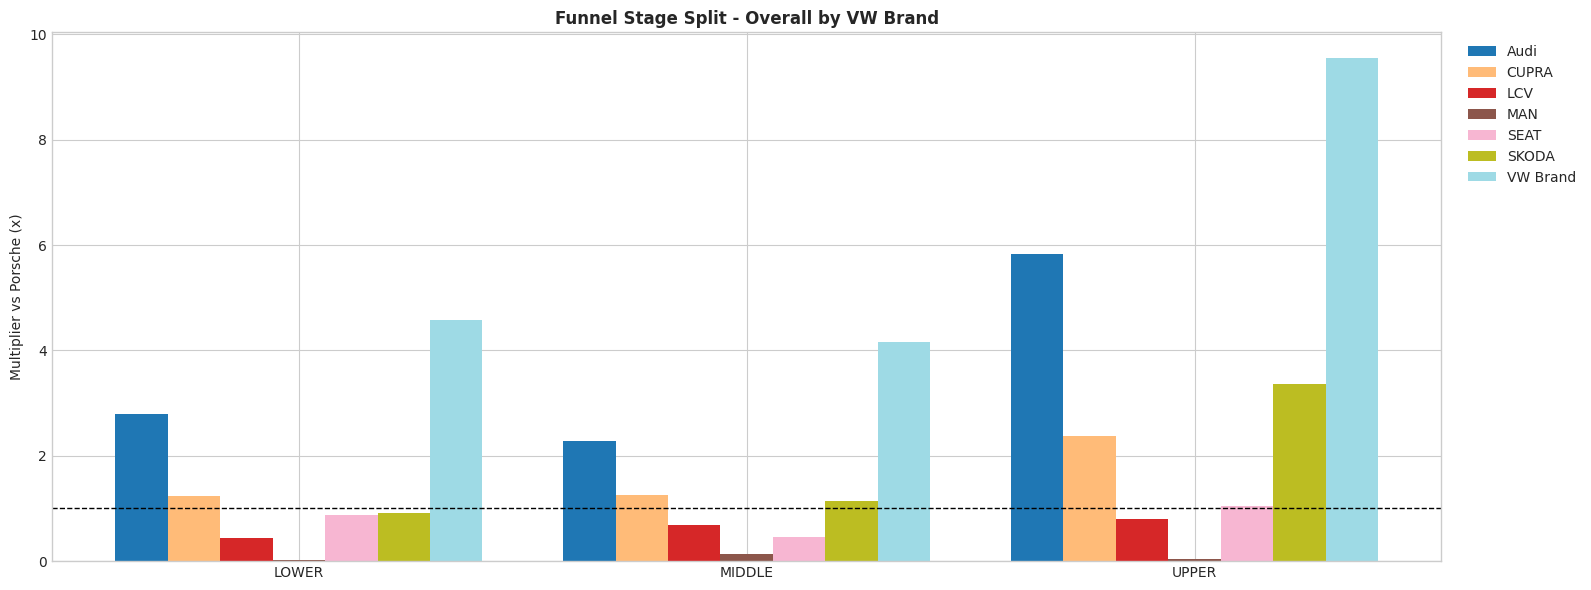

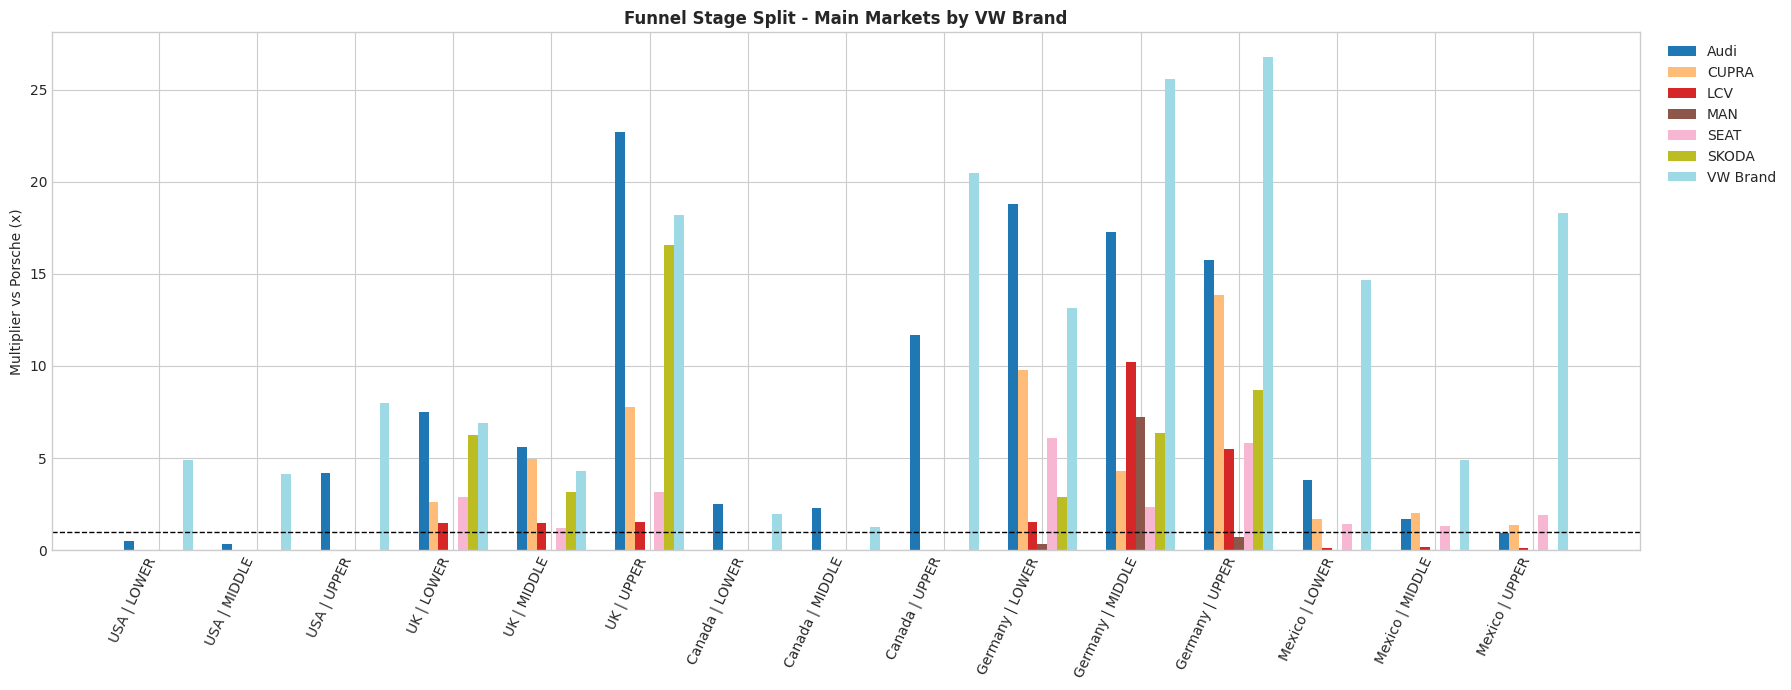

In [303]:
# Plot 3 - Funnel stage split overall and by main market (brand comparison)

stage_map_brand = {
    'Search': 'LOWER',
    'Social': 'MIDDLE',
    'Display': 'MIDDLE',
    'Digital I/O': 'MIDDLE',
    'Other': 'MIDDLE',
    'Dig. Video': 'UPPER',
    'Video': 'UPPER',
    'Programmatic Video': 'UPPER',
    'TV': 'UPPER',
    'Print': 'UPPER',
    'OOH': 'UPPER',
    'Radio': 'UPPER',
    'Cinema': 'UPPER',
}

vw_stage = vw.copy()
vw_stage['funnel_stage'] = vw_stage['media'].map(stage_map_brand).fillna('MIDDLE')

# overall: multiplier by funnel stage and brand vs Porsche
p_stage = (
    vw_stage[vw_stage['brand_clean'].str.upper() == 'PORSCHE']
    .groupby('funnel_stage', as_index=False)['spend_eur'].sum()
    .rename(columns={'spend_eur': 'porsche_spend'})
)

c_stage_brand = (
    vw_stage[vw_stage['brand_clean'].str.upper() != 'PORSCHE']
    .groupby(['brand_clean', 'funnel_stage'], as_index=False)['spend_eur'].sum()
)

overall_fb = c_stage_brand.merge(p_stage, on='funnel_stage', how='inner')
overall_fb['multiplier'] = overall_fb['spend_eur'] / overall_fb['porsche_spend']

stage_order = ['LOWER', 'MIDDLE', 'UPPER']
overall_mat = overall_fb.pivot_table(index='funnel_stage', columns='brand_clean', values='multiplier', aggfunc='mean').reindex(stage_order)
brands = list(overall_mat.columns)

x = np.arange(len(overall_mat.index))
n = max(len(brands), 1)
width = min(0.82 / n, 0.12)
colors = plt.cm.tab20(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(16, 6))
for i, b in enumerate(brands):
    vals = overall_mat[b].values if b in overall_mat.columns else np.zeros(len(overall_mat))
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=b, color=colors[i])

ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(stage_order)
ax.set_ylabel('Multiplier vs Porsche (x)')
ax.set_title('Funnel Stage Split - Overall by VW Brand', fontsize=12, weight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout()
plt.show()

# by main market: brand comparison by funnel stage (grouped on market-stage combinations)
main_stage = vw_stage[vw_stage['market'].isin(vw_main_markets)].copy()

p_ms = (
    main_stage[main_stage['brand_clean'].str.upper() == 'PORSCHE']
    .groupby(['market', 'funnel_stage'], as_index=False)['spend_eur'].sum()
    .rename(columns={'spend_eur': 'porsche_spend'})
)

c_ms = (
    main_stage[main_stage['brand_clean'].str.upper() != 'PORSCHE']
    .groupby(['brand_clean', 'market', 'funnel_stage'], as_index=False)['spend_eur'].sum()
)

ms = c_ms.merge(p_ms, on=['market', 'funnel_stage'], how='inner')
ms['multiplier'] = ms['spend_eur'] / ms['porsche_spend']
ms['key'] = ms['market'] + ' | ' + ms['funnel_stage']

key_order = []
for m in vw_main_markets:
    for s in stage_order:
        key_order.append(f'{m} | {s}')

ms_mat = ms.pivot_table(index='key', columns='brand_clean', values='multiplier', aggfunc='mean').reindex(key_order)

x = np.arange(len(ms_mat.index))
n = max(len(ms_mat.columns), 1)
width = min(0.82 / n, 0.10)
colors = plt.cm.tab20(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(18, 7))
for i, b in enumerate(ms_mat.columns):
    vals = ms_mat[b].values
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=b, color=colors[i])

ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(ms_mat.index, rotation=65, ha='right')
ax.set_ylabel('Multiplier vs Porsche (x)')
ax.set_title('Funnel Stage Split - Main Markets by VW Brand', fontsize=12, weight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout()
plt.show()

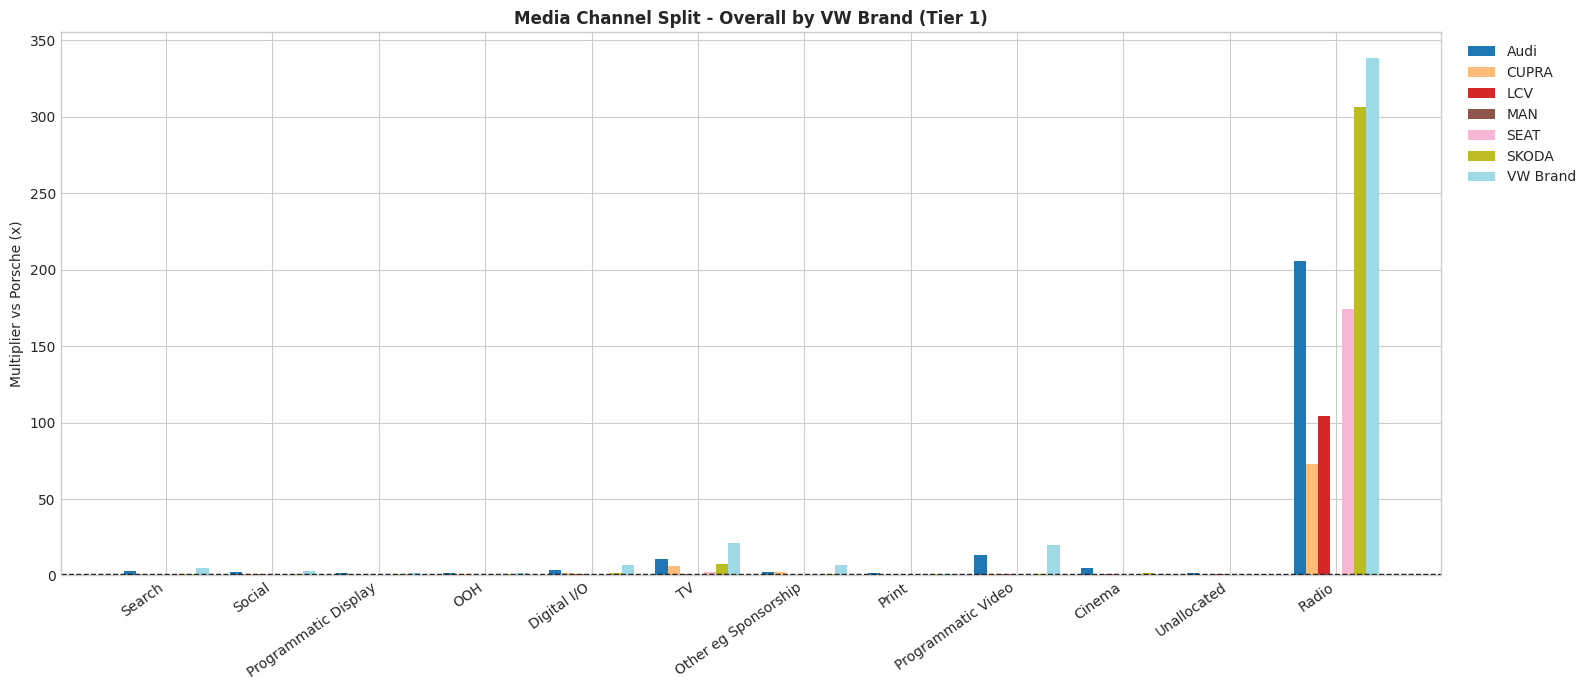

VW brands included: ['Audi', 'CUPRA', 'LCV', 'MAN', 'SEAT', 'SKODA', 'VW Brand']


In [304]:
# Plot 2c - Media channel split overall by ALL VW brands (Tier 1)

# Porsche spend by channel (overall)
p_channel = vw_p.groupby('media', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'porsche_spend'})

# Competitor spend by brand + channel
c_brand_channel = vw_c.groupby(['brand_clean', 'media'], as_index=False)['spend_eur'].sum()

# multiplier vs Porsche per brand-channel
brand_channel_mult = c_brand_channel.merge(p_channel, on='media', how='inner')
brand_channel_mult['multiplier'] = brand_channel_mult['spend_eur'] / brand_channel_mult['porsche_spend']

# order channels by Porsche importance
channel_order = p_channel.sort_values('porsche_spend', ascending=False)['media'].tolist()
plot_df = brand_channel_mult.pivot_table(index='media', columns='brand_clean', values='multiplier', aggfunc='mean').reindex(channel_order)
all_brands = list(plot_df.columns)

x = np.arange(len(plot_df.index))
n_brands = max(len(all_brands), 1)
width = min(0.8 / n_brands, 0.18)

fig, ax = plt.subplots(figsize=(16, 7))
colors = plt.cm.tab20(np.linspace(0, 1, n_brands))

for i, brand in enumerate(all_brands):
    vals = plot_df[brand].values if brand in plot_df.columns else np.zeros(len(plot_df))
    offset = (i - (n_brands - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=brand, color=colors[i])

ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=35, ha='right')
ax.set_ylabel('Multiplier vs Porsche (x)')
ax.set_title('Media Channel Split - Overall by VW Brand (Tier 1)', fontsize=12, weight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout()
plt.show()

print('VW brands included:', all_brands)

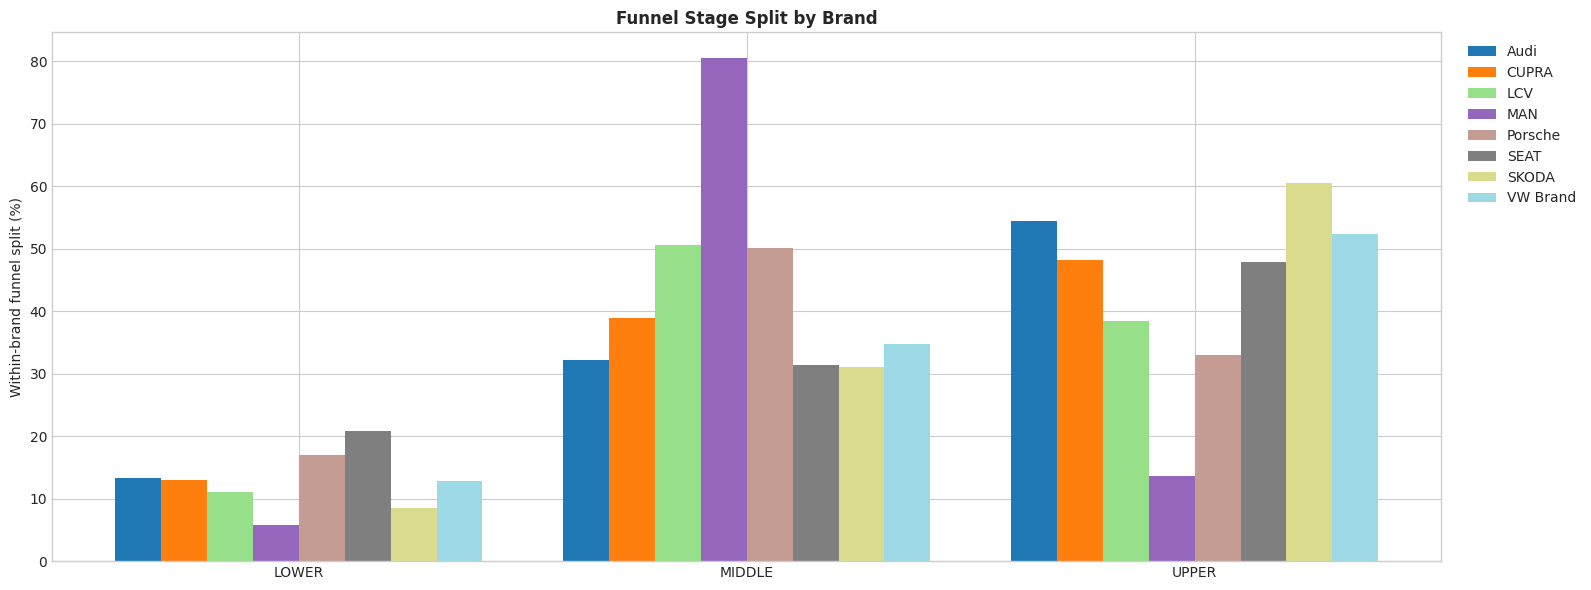

In [305]:
# Plot 3c - Funnel stage split by brand (individual brands)

stage_map_brand = {
    'Search': 'LOWER',
    'Social': 'MIDDLE',
    'Display': 'MIDDLE',
    'Digital I/O': 'MIDDLE',
    'Other': 'MIDDLE',
    'Dig. Video': 'UPPER',
    'Video': 'UPPER',
    'Programmatic Video': 'UPPER',
    'TV': 'UPPER',
    'Print': 'UPPER',
    'OOH': 'UPPER',
    'Radio': 'UPPER',
    'Cinema': 'UPPER',
}

vw_stage = vw.copy()
vw_stage['funnel_stage'] = vw_stage['media'].map(stage_map_brand).fillna('MIDDLE')

# spend by brand x funnel stage
brand_stage = vw_stage.groupby(['brand_clean', 'funnel_stage'], as_index=False)['spend_eur'].sum()

# convert to within-brand split (%) for comparability
brand_totals = brand_stage.groupby('brand_clean', as_index=False)['spend_eur'].sum().rename(columns={'spend_eur': 'brand_total'})
brand_stage = brand_stage.merge(brand_totals, on='brand_clean', how='left')
brand_stage['split_pct'] = 100 * brand_stage['spend_eur'] / brand_stage['brand_total']

stage_order = ['LOWER', 'MIDDLE', 'UPPER']
mat = brand_stage.pivot_table(index='funnel_stage', columns='brand_clean', values='split_pct', aggfunc='sum').reindex(stage_order)

brands = list(mat.columns)
x = np.arange(len(mat.index))
n = max(len(brands), 1)
width = min(0.82 / n, 0.12)
colors = plt.cm.tab20(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(16, 6))
for i, b in enumerate(brands):
    vals = mat[b].values if b in mat.columns else np.zeros(len(mat))
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, vals, width, label=b, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(stage_order)
ax.set_ylabel('Within-brand funnel split (%)')
ax.set_title('Funnel Stage Split by Brand', fontsize=12, weight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)

plt.tight_layout()
plt.show()